In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# читаем файлы
df_Lic = pd.read_csv('df_License.csv', encoding='windows-1251', sep=';')
df_Lic_reg = pd.read_csv('df_License_region.csv', encoding='windows-1251', sep=';')
df_company = pd.read_csv('df_company.csv', encoding='windows-1251', sep=';')

In [13]:
pd.set_option('display.max_columns', 500)

## **DF - df_Lic. Информация о статусе лицензии**

In [15]:
# Датафрейм с действующими лицензиями
df_Lic.head(2)

,Регистрационный номер лицензии,Статус лицензии,День начала оказания услуг,Срок действия до,ИНН,Территория действия лицензии,"Лицензируемый вид деятельности с указанием выполняемых работ, составляющих лицензируемый вид деятельности",Регион_Лицензии
0,Л030-00114-77/00072310,действующая,29.09.2019,29.09.2029,317002737,Республика Бурятия: Северобайкальск г,Услуги связи для целей эфирного вещания,Республика Бурятия
1,Л030-00114-77/00070257,действующая,21.05.2019,21.11.2028,507020170,"Республика Дагестан: Дубки, Чиркей",Услуги связи для целей эфирного вещания,Республика Дагестан


In [22]:
q_lis = len(df_Lic['Лицензируемый вид деятельности с указанием выполняемых работ, составляющих лицензируемый вид деятельности'].unique())

In [27]:
# посмотрим виды лицензий
print(f'Кол-во видов лицензий: {q_lis}')
print('')
a = 0
for i in df_Lic['Лицензируемый вид деятельности с указанием выполняемых работ, составляющих лицензируемый вид деятельности'].unique():
  a += 1
  print(f'{a}) {i}')

Кол-во видов лицензий: 19

1) Услуги связи для целей эфирного вещания
2) Услуги связи по передаче данных, за исключением услуг связи по передаче данных для целей передачи голосовой информации
3) Телематические услуги связи
4) Услуги связи для целей кабельного вещания
5) Услуги связи по предоставлению каналов связи
6) Услуги местной телефонной связи, за исключением услуг местной телефонной связи с использованием таксофонов и средств коллективного доступа
7) Услуги связи для целей проводного радиовещания
8) Услуги связи по передаче данных для целей передачи голосовой информации
9) Услуги подвижной радиосвязи в выделенной сети связи
10) Услуги внутризоновой телефонной связи
11) Услуги междугородной и международной телефонной связи
12) Услуги подвижной радиотелефонной связи
13) Услуги местной телефонной связи с использованием средств коллективного доступа
14) Услуги местной телефонной связи с использованием таксофонов
15) Услуги почтовой связи
16) Услуги телефонной связи в выделенной сети 

In [32]:
# Посмотрим самые популярные лицензии связи
p_t = (
    df_Lic
    .groupby('Лицензируемый вид деятельности с указанием выполняемых работ, составляющих лицензируемый вид деятельности')[['Регистрационный номер лицензии']]
    .nunique()
    .rename(columns={'Регистрационный номер лицензии': 'Кол-во лицензий'})
    .sort_values('Кол-во лицензий', ascending=False)
)

display(p_t)

,Кол-во лицензий
"Лицензируемый вид деятельности с указанием выполняемых работ, составляющих лицензируемый вид деятельности",
Телематические услуги связи,6077
"Услуги связи по передаче данных, за исключением услуг связи по передаче данных для целей передачи голосовой информации",5399
Услуги связи для целей эфирного вещания,3590
Услуги связи по предоставлению каналов связи,3294
"Услуги местной телефонной связи, за исключением услуг местной телефонной связи с использованием таксофонов и средств коллективного доступа",1956
Услуги связи для целей кабельного вещания,1902
Услуги связи по передаче данных для целей передачи голосовой информации,1775
Услуги подвижной радиотелефонной связи,511
Услуги внутризоновой телефонной связи,354


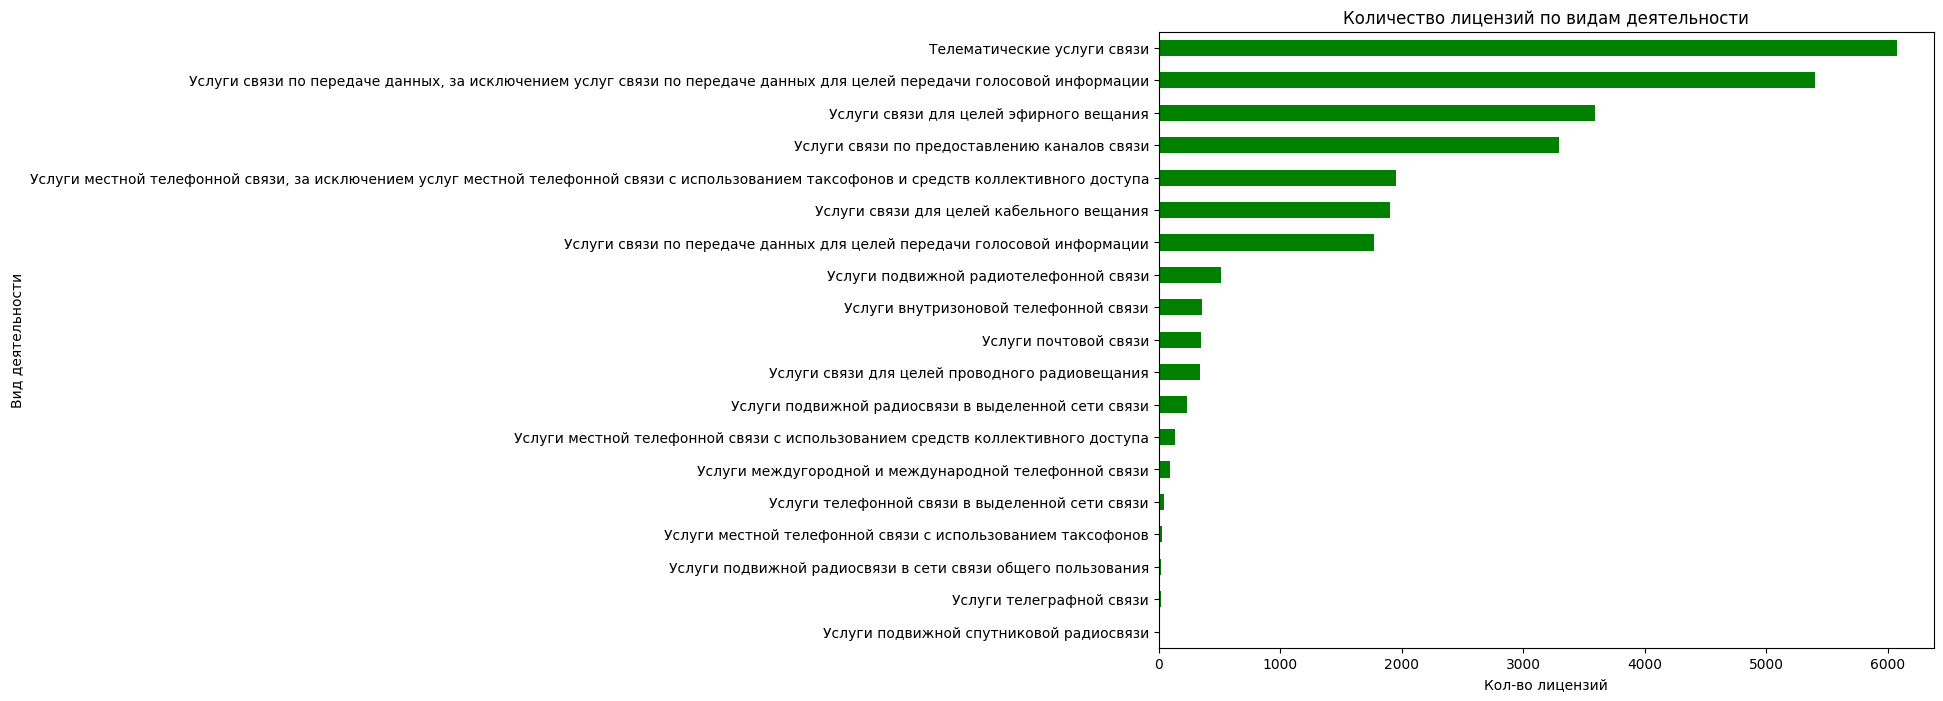

In [36]:
# посмотрим популярность лицензий в формате графиков
p_t.plot(kind='barh', figsize=(10, 8), legend=False, color='green')
plt.xlabel('Кол-во лицензий')
plt.ylabel('Вид деятельности')
plt.title('Количество лицензий по видам деятельности')
plt.gca().invert_yaxis()
plt.show()

## **DF - df_Lic_reg. Информация о регионах расспространения лицензий**

In [37]:
df_Lic_reg.head(5)

,Регистрационный номер лицензии,Регион_Лицензии
0,Л030-00114-77/00072310,Республика Бурятия
1,Л030-00114-77/00070257,Республика Дагестан
2,Л030-00114-77/00073326,Иркутская область
3,Л030-00114-77/00069417,Иркутская область
4,Л030-00114-77/00070479,Иркутская область


In [40]:
# Посмотрим уникальные регионы
q_reg = len(df_Lic_reg['Регион_Лицензии'].unique())
print(f'кол-во регионов - {q_reg}')
print('')
print(df_Lic_reg['Регион_Лицензии'].unique())

кол-во регионов - 93

['Республика Бурятия' 'Республика Дагестан' 'Иркутская область'
 'Российская Федерация' 'Ставропольский край' 'Калужская область'
 'Московская область' 'Тульская область' 'Мурманская область'
 'Ямало-Ненецкий автономный округ' 'Москва' 'Нижегородская область'
 'Республика Татарстан (Татарстан)' 'Самарская область' 'Тверская область'
 'Хабаровский край' 'Псковская область' 'Краснодарский край'
 'Тамбовская область' 'Кемеровская область - Кузбасс'
 'Кемеровская область' 'Челябинская область' 'Республика Хакасия'
 'Ханты-Мансийский автономный округ - Югра' 'Курская область'
 'Республика Мордовия' 'Тюменская область'
 'Чувашская Республика - Чувашия' 'Республика Саха (Якутия)'
 'Сахалинская область' 'Приморский край' 'Республика Адыгея (Адыгея)'
 'Чукотский автономный округ' 'Кировская область' 'Санкт-Петербург'
 'Байконур' 'Красноярский край' 'Новосибирская область'
 'Новгородская область' 'Республика Башкортостан' 'Чеченская Республика'
 'Республика Ингушетия' 'Респ

### DF - df_com. Информация о компаниях

In [41]:
df_company.head()

,Полное наименование лицензиата,Сокращенное наименование,Организационно-правовая форма,Адрес места нахождения,ОГРН,ИНН,Номер телефона,Адрес электронной почты,Регион
0,"""СТВ"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ",ООО СТВ,Общества с ограниченной ответственностью,"671701, РЕСПУБЛИКА БУРЯТИЯ, Г. СЕВЕРОБАЙКАЛЬСК...",1020300796229,317002737,8-914-899-15-10,Ioganson@yandex.ru,республика бурятия
1,"""ИСТОК"" ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ","""ИСТОК"" ООО",Общества с ограниченной ответственностью,"368219, РЕСПУБЛИКА ДАГЕСТАН, БУЙНАКСКИЙ Р-Н, С...",1020500715377,507020170,(989) 483-17-77,muhtar1937@mail.ru,республика дагестан
2,"""ОБЩЕСТВО С ОГРАНИЧЕННОЙ ОТВЕТСТВЕННОСТЬЮ ""КСИ...","ООО ""КС""",Общества с ограниченной ответственностью,"666682, ИРКУТСКАЯ ОБЛАСТЬ, Г. УСТЬ-ИЛИМСК, УЛ....",1023802005292,3817017430,8 (914) 899-15-10,ioganson@yandex.ru,иркутская область
3,АВТОНОМНАЯ НЕКОММЕРЧЕСКАЯ ОБРАЗОВАТЕЛЬНАЯ ОРГА...,"АНОО ДО ""ЦОР""",Автономные некоммерческие организации,"690014, ПРИМОРСКИЙ КРАЙ, Г ВЛАДИВОСТОК, УЛ ГОГ...",1112500001734,2536970156,(4232) 404-175,galina.gerasimova@vvsu.ru,приморский край
4,"АВТОНОМНАЯ НЕКОММЕРЧЕСКАЯ ОРГАНИЗАЦИЯ ""ДУХОВНО...","ДПЦ ""ГРАД КРЕСТА""",Автономные некоммерческие организации,"355017, СТАВРОПОЛЬСКИЙ КРАЙ, Г СТАВРОПОЛЬ, УЛ ...",1182651002379,2635233322,+7 962 000-00-74,alsk07@mail.ru,ставропольский край


In [46]:
q_inn = len(df_company['ИНН'].unique())
print(f'кол-во уникальных ИНН - {q_inn }')

кол-во уникальных ИНН - 8938


In [49]:
q_reg =  len(df_company['Регион'].unique())
print(f'кол-во уникальных Регионов - {q_reg}')
print('')
df_company['Регион'].unique()

кол-во уникальных Регионов - 91



array(['республика бурятия', 'республика дагестан', 'иркутская область',
       'приморский край', 'ставропольский край', 'московская область',
       'мурманская область', 'ямало-ненецкий автономный округ',
       'г.москва', 'нижегородская область',
       'республика татарстан (татарстан)', 'самарская область',
       'тверская область', 'хабаровский край', 'псковская область',
       'краснодарский край', 'тамбовская область',
       'кемеровская область - кузбасс', 'челябинская область',
       'республика хакасия', 'ханты-мансийский автономный округ - югра',
       'курская область', 'республика мордовия',
       'чувашская республика - чувашия', 'республика саха (якутия)',
       'новосибирская область', 'сахалинская область',
       'республика адыгея (адыгея)', 'красноярский край',
       'чукотский автономный округ', 'кировская область',
       'г.санкт-петербург', 'вологодская область', 'новгородская область',
       'республика башкортостан', 'чеченская республика',
       

In [50]:
# Создаем сводную таблицу
p_r_1 = df_company.pivot_table(
    index='Регион',  # или 'Регион_Лицензии', если нужно
    values='ИНН',
    aggfunc='nunique'  # считаем уникальные ИНН
).sort_values('ИНН', ascending=False)

In [51]:
display(p_r_1)

,ИНН
Регион,
г.москва,1726
Не установлено,865
московская область,671
г.санкт-петербург,611
свердловская область,252
...,...
херсонская область,6
чукотский автономный округ,5
г.байконур,4
